对数据进行预处理

In [1]:
import numpy as np
import pandas as pd

# data load
file = pd.read_csv("D:\datas\pima\diabetes.csv")
train = file.copy()
train.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


1.pre_processing stage

In [2]:
# tentative exploration
train.info()
# no NaN

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [3]:
train.describe()
# pre feature's min is 0.As us we konw,some features is 0 represents
# that it's no meaning such as BMI etc.So we ought to deal with these datas.

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [4]:
cols_with_zero = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
train[cols_with_zero] = train[cols_with_zero].replace(0,np.nan)
train.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [5]:
# evalulate the value of features
# for features with a large number of missing values,we need to
# determine whether they are relevant to the Outcome and what 
# kind of handing we should do with them
train['SkinThickness_missing'] = train['SkinThickness'].apply(lambda x:1 if pd.isnull(x) else 0)
train[['SkinThickness','SkinThickness_missing','Outcome']].head(10)

,SkinThickness,SkinThickness_missing,Outcome
0,35.0,0,1
1,29.0,0,0
2,NaN,1,1
3,23.0,0,0
4,35.0,0,1
5,NaN,1,0
6,32.0,0,1
7,NaN,1,0
8,45.0,0,1
9,NaN,1,1


<Axes: xlabel='SkinThickness_missing', ylabel='count'>

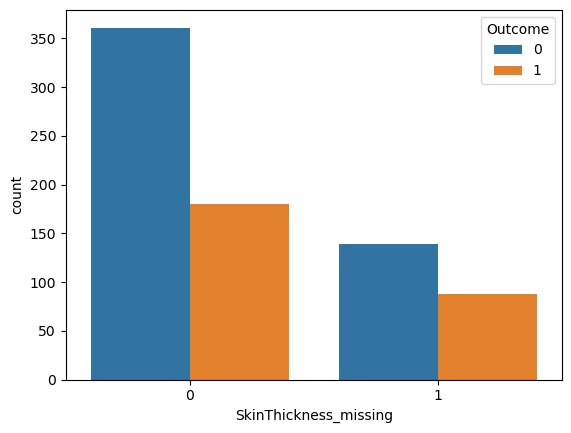

In [6]:
# use picture to show their relevant 
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.countplot(x='SkinThickness_missing',hue='Outcome',data=train)

<Axes: xlabel='Insulin_missing', ylabel='count'>

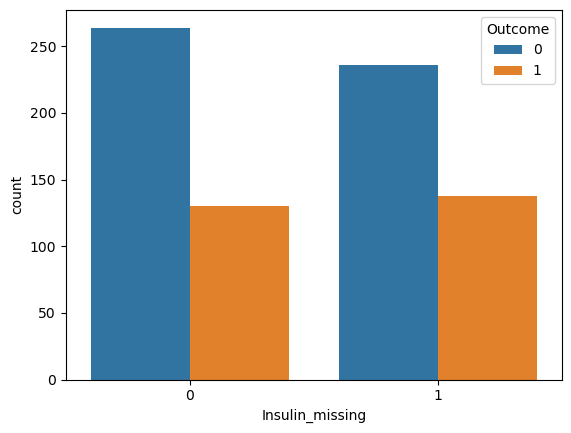

In [7]:
# repeat the above steps
train['Insulin_missing'] = train['Insulin'].apply(lambda x:1 if pd.isnull(x) else 0)
sns.countplot(x='Insulin_missing',hue='Outcome',data=train)

In [8]:
# the above images show there is no relevant . we use KNN to fill nan.
train.drop(['SkinThickness_missing','Insulin_missing'],axis=1,inplace=True)

In [9]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)
train = pd.DataFrame(imputer.fit_transform(train),columns=train.columns)
train.head()
train.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.598177,72.371354,29.114583,153.180208,32.427344,0.471876,33.240885,0.348958
std,3.369578,30.496543,12.206417,9.424100,98.385308,6.886588,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,23.000000,87.900000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,133.700000,32.090000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,35.000000,190.150000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


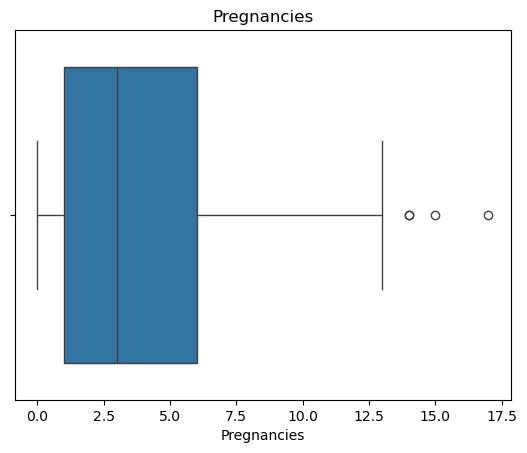

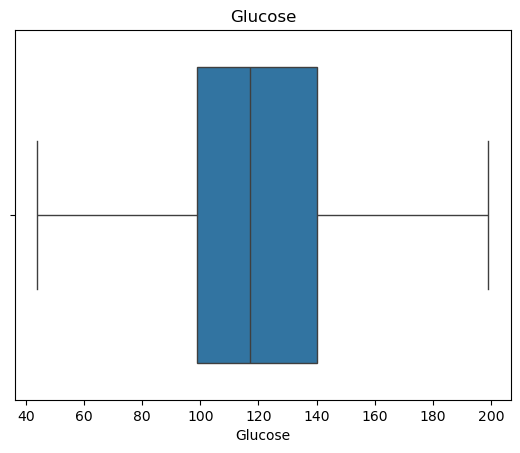

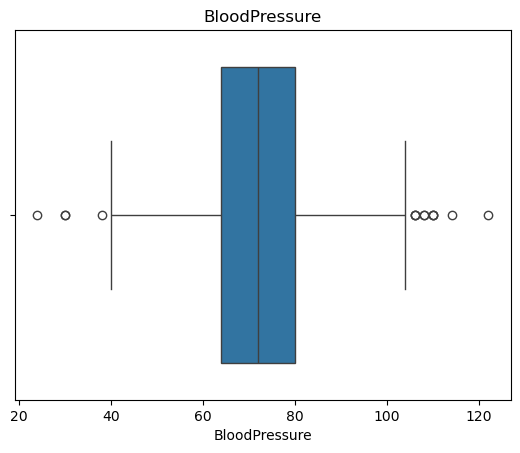

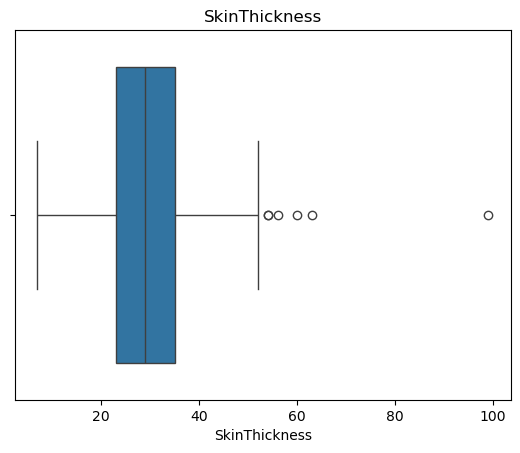

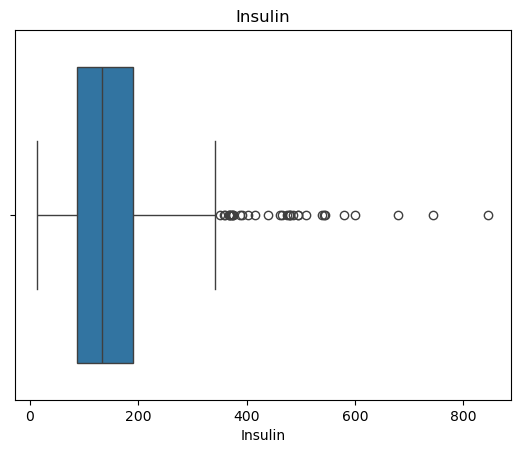

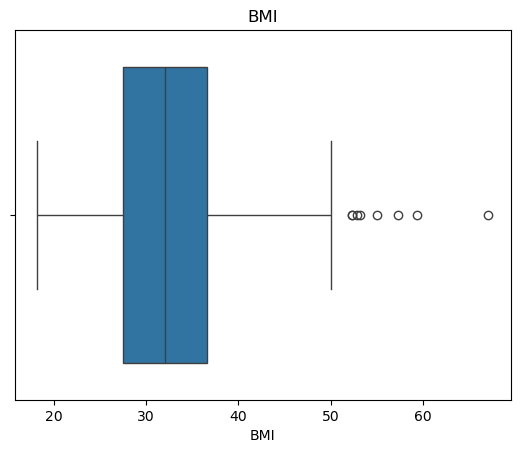

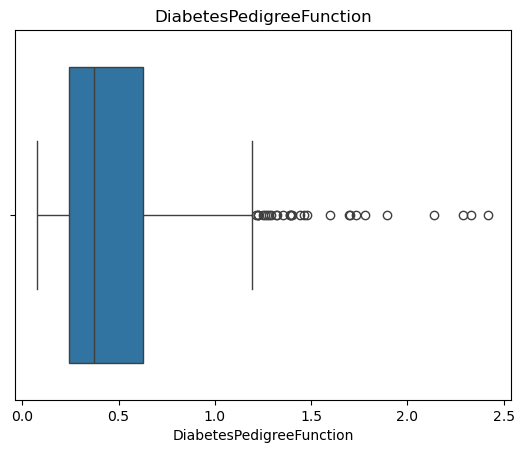

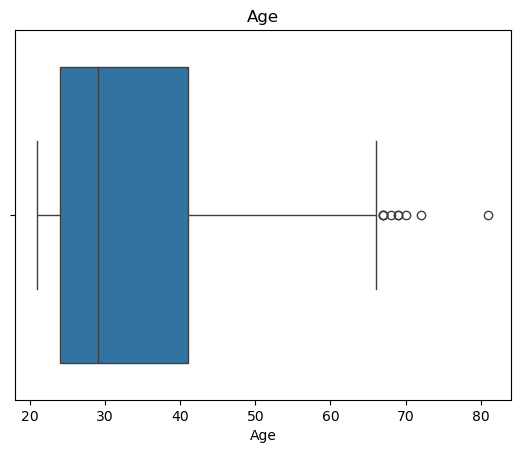

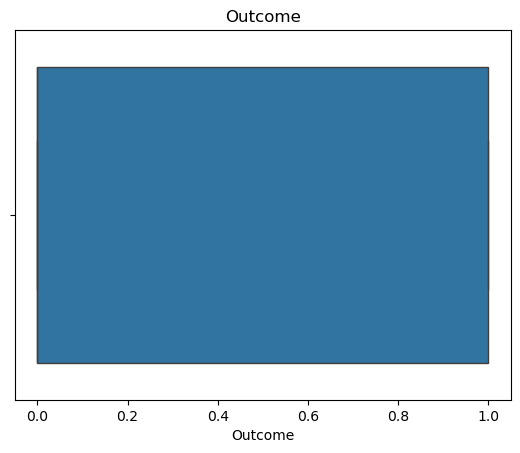

In [10]:
# now perform outlier detection and processing
for col in train.select_dtypes(include=[np.number]).columns:
    plt.figure()
    sns.boxplot(x=train[col])
    plt.title(col)
    plt.show()

In [11]:
# then standardize the data
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# # # get labels
# X_train = train.drop(['Outcome'],axis=1)
# y_train = train['Outcome']
# feat_names = X_train.columns

# X_train = scaler.fit_transform(X_train)
# X_train.shape

In [12]:
# then handle class imbalance
# from imblearn.over_sampling import SMOTE
# smote = SMOTE(random_state=42)
# X_train,y_train = smote.fit_resample(X_train,y_train)
# y_train.shape

In [13]:
# save the results of the feartue processing as a file
# X_train = pd.DataFrame(columns=feat_names,data=X_train)
# train = pd.concat([X_train,y_train],axis=1)
# train.to_csv('FE_pima.csv',index=False,header=True)

In [14]:
train.to_csv("../datasets/process_pima.csv",index=False,header=True)